In [4]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from networks.inflammation_network import to_coral
from networks.inflammation_network import build_dataloaders
from networks.inflammation_network import InflammationModel

con = duckdb.connect('../capillary.db')

df = con.execute("""
                SELECT 
                        p.row_id,
                        any_value(pid) as pid, 
                        any_value(value) as value,
                        any_value(fractions) as fractions,
                        any_value(boundaries) as boundaries,
                        any_value(albumin) as albumin,
                        any_value(antitrypsin) as antitrypsin,
                        any_value(orosomukoid) as orosomukoid,
                        any_value(haptoglobin) as haptoglobin,
                        any_value(crp) as crp,
                        any_value(igg) as igg,
                        any_value(iga) as iga,
                        any_value(igm) as igm,
                        list(c.comment_nr) as comment_nr,
                        any_value(age) as age,
                        any_value(sign) as sign,
                        any_value(set) as set,
                    FROM protein_data p
                    LEFT JOIN comment_precences c 
                        ON p.row_id = c.row_id
                    WHERE p.row_id IN (
                        SELECT row_id FROM comment_precences 
                        WHERE comment_nr BETWEEN 16 AND 27
                    )
                    GROUP BY p.row_id
                """).df()


con.close()

def get_inflammation_comment(comments):
    for i in range(16, 28):
        if i in comments:
            return i
    return None


df['inflammation_comment'] = df['comment_nr'].apply(get_inflammation_comment)
df = df[df['inflammation_comment'].notna()]

counts = df['inflammation_comment'].value_counts()
most_frequent = counts.max()
position_weights = [most_frequent / counts.get(i, 1) for i in range(16, 28)]

df['label'] = df['inflammation_comment'].apply(to_coral)
train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

print(counts.sort_index())

train_dl, val_dl, test_dl = build_dataloaders(train_rows, val_rows, test_rows)
inflammation_model = InflammationModel()
inflammation_model.retrain(train_dl,val_dl)

inflammation_comment
16     1233
17     8853
18     8885
19     3470
20    78286
21    10727
22    28592
23     7249
24     4799
25     1558
26     5927
27      235
Name: count, dtype: int64
Epoch   0 | train: 0.0709 | val: 0.0673 | MAE: 0.241 | lr: 0.001000
  -> ny bästa modell sparad
Epoch   1 | train: 0.0703 | val: 0.0673 | MAE: 0.235 | lr: 0.001000
  -> ny bästa modell sparad
Epoch   2 | train: 0.0704 | val: 0.0672 | MAE: 0.232 | lr: 0.001000
  -> ny bästa modell sparad
Epoch   3 | train: 0.0699 | val: 0.0670 | MAE: 0.229 | lr: 0.001000
  -> ny bästa modell sparad
Epoch   4 | train: 0.0703 | val: 0.0667 | MAE: 0.229 | lr: 0.001000
  -> ny bästa modell sparad
Epoch   5 | train: 0.0700 | val: 0.0683 | MAE: 0.233 | lr: 0.001000
Epoch   6 | train: 0.0700 | val: 0.0677 | MAE: 0.232 | lr: 0.001000
Epoch   7 | train: 0.0697 | val: 0.0667 | MAE: 0.235 | lr: 0.001000
  -> ny bästa modell sparad
Epoch   8 | train: 0.0694 | val: 0.0667 | MAE: 0.224 | lr: 0.001000
Epoch   9 | train: 0.0695 | v

MAE:          0.278
Exakt rätt:   80.6%
Inom ±1 grad: 93.9%
Inom ±2 grad: 98.8%
The bias is: -0.007865546271204948
inflammation level: 0 | predicted amount within 1 unit: 3753 | true amount within 1 unit: 3762
inflammation level: 1 | predicted amount within 1 unit: 4008 | true amount within 1 unit: 3936
inflammation level: 2 | predicted amount within 1 unit: 2473 | true amount within 1 unit: 4392
inflammation level: 3 | predicted amount within 1 unit: 2884 | true amount within 1 unit: 6666
inflammation level: 4 | predicted amount within 1 unit: 924 | true amount within 1 unit: 6992
inflammation level: 5 | predicted amount within 1 unit: 336 | true amount within 1 unit: 7211
inflammation level: 6 | predicted amount within 1 unit: 313 | true amount within 1 unit: 7266
inflammation level: 7 | predicted amount within 1 unit: 334 | true amount within 1 unit: 7554
inflammation level: 8 | predicted amount within 1 unit: 99 | true amount within 1 unit: 7562
inflammation level: 9 | predicted am

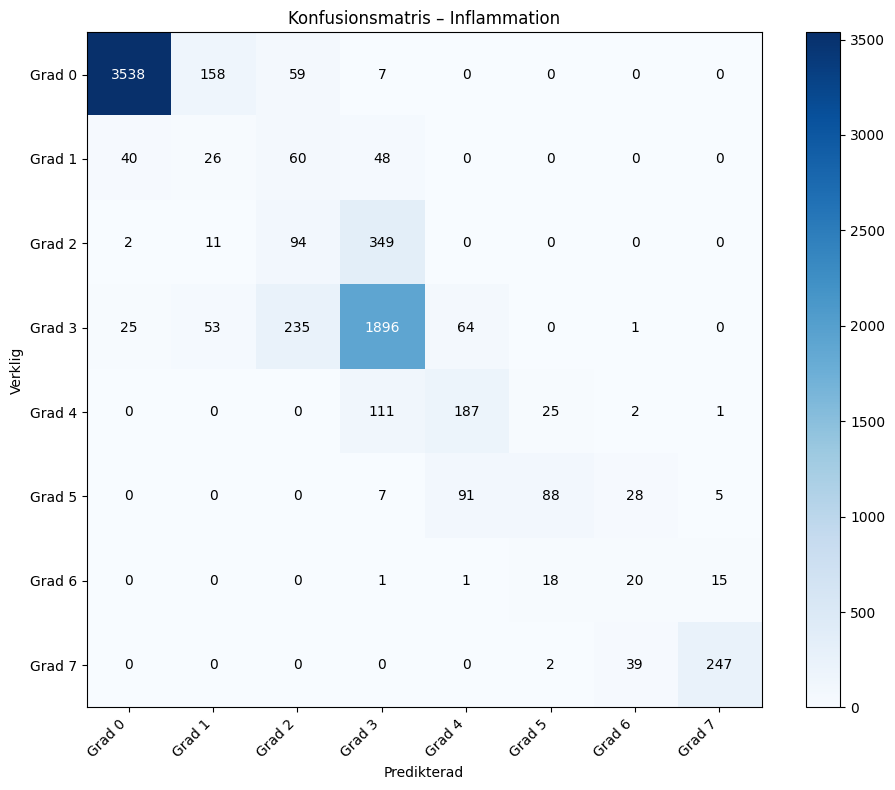

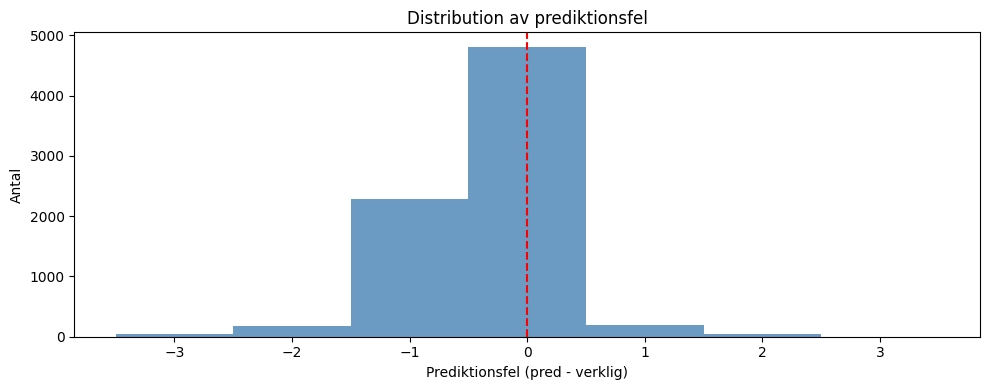

In [5]:
inflammation_model.evaluate_inflammation(val_dl)

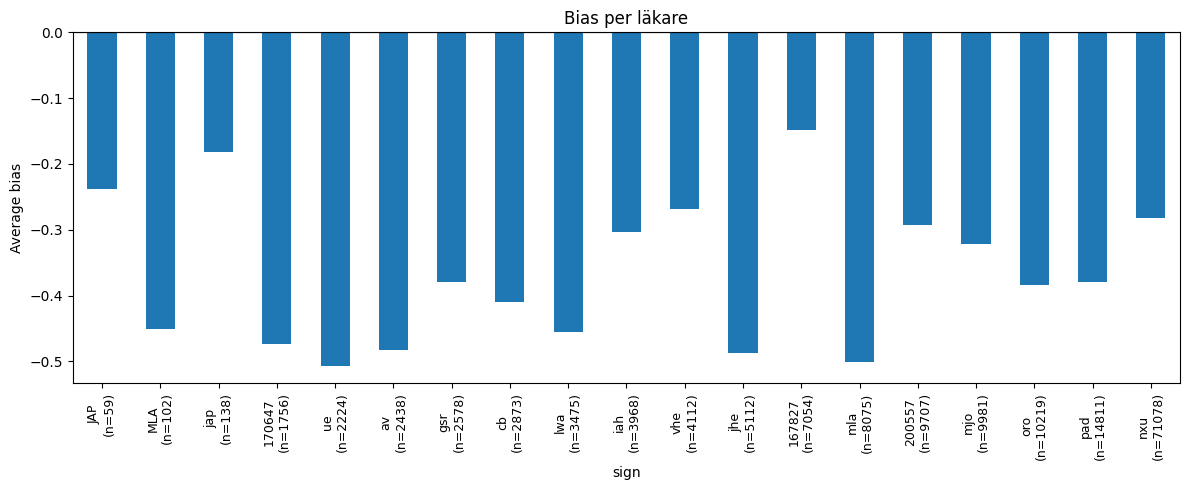

In [6]:

# Kör prediktioner på hela df
df = inflammation_model.predict(df)  # Lägger till df['inflammation']

# Lägg till true severity
from matplotlib import pyplot as plt

from networks.inflammation_network import to_severity
df['severity'] = df['inflammation_comment'].apply(to_severity)

# Analys
result = df[df['severity'].notna() & df['inflammation'].notna()].copy()
result['error'] = result['inflammation'] - result['severity']

summary = pd.DataFrame({
    'antal': result.groupby('sign').size(),
    'bias':  result.groupby('sign')['error'].mean()
}).sort_values('antal', ascending=False)

summary = summary[summary['antal'] > 50]
summary_sorted = summary.sort_values('antal')

labels = [f"{sign}\n(n={int(antal)})" for sign, antal in zip(summary_sorted.index, summary_sorted['antal'])]
summary_sorted['bias'].plot(kind='bar', figsize=(12, 5))
plt.xticks(range(len(labels)), labels, fontsize=9)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Average bias")
plt.title("Bias per läkare")
plt.tight_layout()
plt.show()